# Phase 6 — Itinerary Analysis & Geographic Validation
## Travel Destination Recommendation System

This notebook provides experimentation, inspection, and analysis of the **Itinerary Generation Module** in the travel recommendation system. It calls the production implementation from `src/itinerary.py` and evaluation metrics from `src/itinerary_evaluation.py` to analyze geographic candidate selection, day clustering, travel pace capacities, and nearest-neighbor sequencing. It is a downstream extension that analyzes feasibility without modifying the underlying recommender logic.

### 1. Imports and Project Setup
We import standard packages, append the project directory to Python's system path, and import components from `src` to run our itinerary experiments.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

# Add project root directory to sys.path to import src
PROJECT_DIR = Path.cwd().parent
sys.path.append(str(PROJECT_DIR))

from src.preprocessing import load_dataset, prepare_attractions, prepare_interactions, train_test_split_by_user
from src.content_based import build_content_column, build_tfidf_matrix, recommend_attractions
from src.itinerary import (
    load_coordinates,
    haversine_distance,
    attach_coordinates,
    order_day,
    build_one_day_itinerary
)
from src.itinerary_evaluation import evaluate_itinerary

### 2. Load Recommendation Candidates
We load the raw datasets and run Content-Based Filtering (CBF) to generate a representative Top-15 recommendation list for target user `149` in the training split. This Top-15 list serves as the candidate pool for itinerary generation.

In [2]:
csv_path = PROJECT_DIR / "data" / "tourism_recommendation_dataset_en.csv"
coords_path = PROJECT_DIR / "data" / "coordinates.csv"

dataset = load_dataset(str(csv_path))
coordinates_df = load_coordinates(str(coords_path))

attraction_df = prepare_attractions(dataset)
interactions_df = prepare_interactions(dataset)
train_df, test_df = train_test_split_by_user(interactions_df, test_ratio=0.2, min_interactions=5, random_state=42)

# CBF setup
content_df = build_content_column(attraction_df)
vectorizer, tfidf_matrix, attraction_index = build_tfidf_matrix(content_df)

# Generate candidates
sample_user_id = 149
candidates_df = recommend_attractions(
    tourist_id=sample_user_id,
    interactions_df=train_df,
    attraction_df=attraction_df,
    tfidf_matrix=tfidf_matrix,
    attraction_index=attraction_index,
    top_n=10
)

print(f"Generated {len(candidates_df)} recommendation candidates for tourist_id={sample_user_id}:")
display(candidates_df)

Generated 10 recommendation candidates for tourist_id=149:


,attraction_uid,attraction_name,attraction_category,city,similarity_score,rank
0,Bai Shan Chang Bai Shan Da Xia Gu (Bai Shan Sh...,Bai Shan Chang Bai Shan Da Xia Gu,Natural Scenery,Bai Shan Shi,0.578340,1
1,"Xiang Hai Zi Ran Bao Hu Qu (Bai Cheng Shi, Jilin)",Xiang Hai Zi Ran Bao Hu Qu,Natural Scenery,Bai Cheng Shi,0.554751,2
2,"Yan Dang Shan (Wen Zhou Shi, Zhejiang)",Yan Dang Shan,Natural Scenery,Wen Zhou Shi,0.548767,3
3,"Qian Shan (An Shan Shi, Liaoning)",Qian Shan,Natural Scenery,An Shan Shi,0.545249,4
4,"Huang Shan (Huang Shan Shi, Anhui)",Huang Shan,Natural Scenery,Huang Shan Shi,0.539388,5
5,"Song Hua Hu (Ji Lin Shi, Jilin)",Song Hua Hu,Natural Scenery,Ji Lin Shi,0.533074,6
6,"Wen Zhou Nan Xi Jiang (Wen Zhou Shi, Zhejiang)",Wen Zhou Nan Xi Jiang,Natural Scenery,Wen Zhou Shi,0.532869,7
7,"Hang Zhou Xi Xi Shi Di (Hang Zhou Shi, Zhejiang)",Hang Zhou Xi Xi Shi Di,Natural Scenery,Hang Zhou Shi,0.531133,8
8,"Mo Gan Shan (Hu Zhou Shi, Zhejiang)",Mo Gan Shan,Natural Scenery,Hu Zhou Shi,0.524820,9
9,"Tian Mu Hu (Chang Zhou Shi, Jiangsu)",Tian Mu Hu,Natural Scenery,Chang Zhou Shi,0.519241,10


### 3. Coordinate Attachment & Proximity Inspection
We attach geodetic coordinates to the candidates and compute their distance (in km) from the highest-ranked (Rank 1) anchor destination.

In [3]:
joined_df = attach_coordinates(candidates_df, coordinates_df)
print(f"Coordinate matched candidates: {len(joined_df)} / {len(candidates_df)}")

# Distance from Rank 1 anchor attraction
anchor = joined_df[joined_df["rank"] == 1].iloc[0]
anchor_lat, anchor_lon = anchor["latitude"], anchor["longitude"]

joined_df["dist_to_anchor_km"] = joined_df.apply(
    lambda r: haversine_distance(anchor_lat, anchor_lon, float(r["latitude"]), float(r["longitude"])),
    axis=1
)

print(f"\nAnchor Attraction (Rank 1): {anchor['attraction_name']} ({anchor['city']})")
display(joined_df[["rank", "attraction_name", "city", "dist_to_anchor_km"]].sort_values("rank"))

Coordinate matched candidates: 10 / 10

Anchor Attraction (Rank 1): Bai Shan Chang Bai Shan Da Xia Gu (Bai Shan Shi)


,rank,attraction_name,city,dist_to_anchor_km
0,1,Bai Shan Chang Bai Shan Da Xia Gu,Bai Shan Shi,0.000000
1,2,Xiang Hai Zi Ran Bao Hu Qu,Bai Cheng Shi,546.242069
2,3,Yan Dang Shan,Wen Zhou Shi,1640.787254
3,4,Qian Shan,An Shan Shi,410.739951
4,5,Huang Shan,Huang Shan Shi,1585.393566
5,6,Song Hua Hu,Ji Lin Shi,208.239117
6,7,Wen Zhou Nan Xi Jiang,Wen Zhou Shi,1664.688627
7,8,Hang Zhou Xi Xi Shi Di,Hang Zhou Shi,1485.822910
8,9,Mo Gan Shan,Hu Zhou Shi,1460.319480
9,10,Tian Mu Hu,Chang Zhou Shi,1409.241674


### 4. Requested Destination Experiments
We test generating one-day itineraries with different requested numbers of destinations using the same Top-N recommendation candidate pool.

This experiment examines how the requested destination count affects the number of attractions retained and the geographic characteristics of the generated itinerary.

In [4]:
destination_exp_results = []

# Test every possible requested destination count from 1 to Top-N
destination_cases = range(1, len(candidates_df) + 1)

for requested_destinations in destination_cases:
    itinerary, excluded = build_one_day_itinerary(
        recommendations_df=candidates_df,
        coordinates_df=coordinates_df,
        num_stops=requested_destinations,
        return_excluded=True
    )

    metrics = evaluate_itinerary(
        itinerary,
        candidates_df
    )

    destination_exp_results.append({
        "Requested Destinations": requested_destinations,
        "Selected Stops": len(itinerary),
        "Excluded Count": len(excluded),
        "Candidate Carryover Rate": metrics["candidate_carryover_rate"],
        "Average Consecutive Distance (km)": metrics["avg_consecutive_distance"],
        "Total Travel Distance (km)": metrics["total_travel_distance"],
        "Geographic Compactness (km)": metrics["geographic_compactness"]
    })

destination_exp_df = pd.DataFrame(destination_exp_results)

display(destination_exp_df)

,Requested Destinations,Selected Stops,Excluded Count,Candidate Carryover Rate,Average Consecutive Distance (km),Total Travel Distance (km),Geographic Compactness (km)
0,1,1,9,0.1,NaN,0.000000,NaN
1,2,2,8,0.2,27.972552,27.972552,13.986279
2,3,2,8,0.2,27.972552,27.972552,13.986279
3,4,2,8,0.2,27.972552,27.972552,13.986279
4,5,2,8,0.2,27.972552,27.972552,13.986279
5,6,2,8,0.2,27.972552,27.972552,13.986279
6,7,2,8,0.2,27.972552,27.972552,13.986279
7,8,2,8,0.2,27.972552,27.972552,13.986279
8,9,2,8,0.2,27.972552,27.972552,13.986279
9,10,2,8,0.2,27.972552,27.972552,13.986279


### 5. One-Day Geographic Selection Analysis
This section examines the geographic selection process used for the one-day itinerary.

The system identifies the most suitable geographic group from the Top-N recommendations and retains up to the requested number of destinations before applying route ordering.

In [5]:
# Use all Top-N candidates to inspect the geographic selection itself
requested_destinations = len(candidates_df)

itinerary, excluded = build_one_day_itinerary(
    recommendations_df=candidates_df,
    coordinates_df=coordinates_df,
    num_stops=requested_destinations,
    return_excluded=True
)

print(f"Top-N candidates: {len(candidates_df)}")
print(f"Geographically selected: {len(itinerary)}")
print(f"Excluded: {len(excluded)}")

print("\n--- Selected Attractions ---")

selected_analysis = itinerary.merge(
    candidates_df[["attraction_uid", "rank"]],
    on="attraction_uid",
    how="left"
)

display(
    selected_analysis[
        [
            "rank",
            "stop_order",
            "attraction_name",
            "city",
            "latitude",
            "longitude"
        ]
    ]
)

print("\n--- Excluded Attractions ---")
if excluded.empty:
    print("No attractions were excluded.")
else:
    display(
        excluded[
            [
                "rank",
                "attraction_name",
                "city",
                "exclusion_reason"
            ]
        ]
    )

Top-N candidates: 10
Geographically selected: 2
Excluded: 8

--- Selected Attractions ---


,rank,stop_order,attraction_name,city,latitude,longitude
0,3,1,Yan Dang Shan,Wen Zhou Shi,28.39358,121.027942
1,7,2,Wen Zhou Nan Xi Jiang,Wen Zhou Shi,28.23810,120.803300



--- Excluded Attractions ---


,rank,attraction_name,city,exclusion_reason
0,1,Bai Shan Chang Bai Shan Da Xia Gu,Bai Shan Shi,geographically_incompatible
1,2,Xiang Hai Zi Ran Bao Hu Qu,Bai Cheng Shi,geographically_incompatible
2,4,Qian Shan,An Shan Shi,geographically_incompatible
3,5,Huang Shan,Huang Shan Shi,geographically_incompatible
4,6,Song Hua Hu,Ji Lin Shi,geographically_incompatible
5,8,Hang Zhou Xi Xi Shi Di,Hang Zhou Shi,geographically_incompatible
6,9,Mo Gan Shan,Hu Zhou Shi,geographically_incompatible
7,10,Tian Mu Hu,Chang Zhou Shi,geographically_incompatible


### 6. One-Day Route Ordering
We inspect the route sequence generated by the Greedy Nearest-Neighbor heuristic using the Haversine distance formula. The route starts from the highest-ranked selected attraction and repeatedly visits the nearest remaining attraction.

In [6]:
route_df = itinerary.sort_values("stop_order").copy()

print("One-Day Route Sequence:")

if route_df.empty:
    print("No attractions were selected.")
else:
    for _, row in route_df.iterrows():
        order = int(row["stop_order"])
        name = row["attraction_name"]
        distance = float(row["distance_from_prev_km"])

        if order == 1:
            print(f"Start -> {name}")
        else:
            print(f"      ↓ {distance:.2f} km")
            print(f"Stop {order} -> {name}")

One-Day Route Sequence:
Start -> Yan Dang Shan
      ↓ 27.97 km
Stop 2 -> Wen Zhou Nan Xi Jiang


### 7. Excluded Recommendations Inspection
We inspect the recommendations excluded from the one-day itinerary to understand why certain candidates were not selected during the geographic selection process.

In [7]:
excluded_df = excluded.copy()

# Current geographic constraint used by the one-day itinerary
max_radius_km = 50.0

# Create attraction_uid in the coordinates dataframe
coordinates_analysis = coordinates_df.copy()

coordinates_analysis["attraction_uid"] = [
    f"{str(name).strip()} ({str(city).strip()}, {str(province).strip()})"
    for name, city, province in zip(
        coordinates_analysis["attraction_name"],
        coordinates_analysis["city"],
        coordinates_analysis["province"]
    )
]

# Recreate coordinate information for the Top-N candidates
analysis_candidates = candidates_df.merge(
    coordinates_analysis[
    ["attraction_uid", "latitude", "longitude"]
    ],
    on="attraction_uid",
    how="left"
)

valid_candidates = analysis_candidates.dropna(
    subset=["latitude", "longitude"]
).copy()

# Identify the same geographic anchor used by the selection logic
best_anchor_index = None
best_group_indices = []
best_anchor_rank = float("inf")

for anchor_index, anchor_row in valid_candidates.iterrows():

    group_indices = []

    for candidate_index, candidate_row in valid_candidates.iterrows():

        distance = haversine_distance(
            anchor_row["latitude"],
            anchor_row["longitude"],
            candidate_row["latitude"],
            candidate_row["longitude"]
        )

        if distance <= max_radius_km:
            group_indices.append(candidate_index)

    anchor_rank = anchor_row["rank"]

    if len(group_indices) > len(best_group_indices):
        best_anchor_index = anchor_index
        best_group_indices = group_indices
        best_anchor_rank = anchor_rank

    elif (
        len(group_indices) == len(best_group_indices)
        and anchor_rank < best_anchor_rank
    ):
        best_anchor_index = anchor_index
        best_group_indices = group_indices
        best_anchor_rank = anchor_rank


# Get the selected geographic anchor
anchor_row = valid_candidates.loc[best_anchor_index]

print(
    f"Geographic Anchor: "
    f"{anchor_row['attraction_name']} "
    f"(Rank {int(anchor_row['rank'])})"
)

print(f"Geographic Constraint: {max_radius_km:.0f} km")


# Add coordinates to excluded recommendations
excluded_analysis = excluded_df.merge(
    coordinates_analysis[
        ["attraction_uid", "latitude", "longitude"]
    ],
    on="attraction_uid",
    how="left"
)


# Create detailed reasons
detailed_reasons = []
distance_to_anchor = []

for _, row in excluded_analysis.iterrows():

    if pd.isna(row["latitude"]) or pd.isna(row["longitude"]):
        distance_to_anchor.append(None)
        detailed_reasons.append(
            "Coordinates unavailable, so geographic suitability "
            "cannot be evaluated."
        )

    else:
        distance = haversine_distance(
            anchor_row["latitude"],
            anchor_row["longitude"],
            row["latitude"],
            row["longitude"]
        )

        distance_to_anchor.append(distance)

        if row["exclusion_reason"] == "geographically_incompatible":
            detailed_reasons.append(
                f"Outside the {max_radius_km:.0f} km geographic "
                f"constraint ({distance:.2f} km from the anchor)."
            )

        elif row["exclusion_reason"] == "not_selected":
            detailed_reasons.append(
                "Geographically suitable, but not selected because "
                "the requested destination limit was reached."
            )

        else:
            detailed_reasons.append(
                row["exclusion_reason"]
            )


excluded_analysis["distance_to_anchor_km"] = distance_to_anchor
excluded_analysis["detailed_reason"] = detailed_reasons


print(f"\nTotal Excluded Candidates: {len(excluded_analysis)}")

print("\nExcluded Candidates Details:")

display(
    excluded_analysis[
        [
            "rank",
            "attraction_name",
            "city",
            "distance_to_anchor_km",
            "detailed_reason"
        ]
    ].sort_values("rank")
)

Geographic Anchor: Yan Dang Shan (Rank 3)
Geographic Constraint: 50 km

Total Excluded Candidates: 8

Excluded Candidates Details:


,rank,attraction_name,city,distance_to_anchor_km,detailed_reason
0,1,Bai Shan Chang Bai Shan Da Xia Gu,Bai Shan Shi,1640.787254,Outside the 50 km geographic constraint (1640....
1,2,Xiang Hai Zi Ran Bao Hu Qu,Bai Cheng Shi,1831.381264,Outside the 50 km geographic constraint (1831....
2,4,Qian Shan,An Shan Shi,1417.731225,Outside the 50 km geographic constraint (1417....
3,5,Huang Shan,Huang Shan Shi,338.285279,Outside the 50 km geographic constraint (338.2...
4,6,Song Hua Hu,Ji Lin Shi,1774.240441,Outside the 50 km geographic constraint (1774....
5,8,Hang Zhou Xi Xi Shi Di,Hang Zhou Shi,228.320537,Outside the 50 km geographic constraint (228.3...
6,9,Mo Gan Shan,Hu Zhou Shi,271.537679,Outside the 50 km geographic constraint (271.5...
7,10,Tian Mu Hu,Chang Zhou Shi,360.107026,Outside the 50 km geographic constraint (360.1...


### 8. Itinerary Evaluation
We call evaluate_itinerary() to evaluate the generated one-day itinerary using four itinerary-specific metrics: Candidate Carryover Rate, Average Consecutive-Stop Distance, Total Travel Distance, and Geographic Compactness.

In [8]:
metrics = evaluate_itinerary(
    itinerary,
    candidates_df
)

print("One-Day Itinerary Evaluation:")

print(
    f"Candidate Carryover Rate: "
    f"{metrics['candidate_carryover_rate']:.2%}"
)

if metrics["avg_consecutive_distance"] is None:
    print("Average Consecutive Distance: N/A")
else:
    print(
        f"Average Consecutive Distance: "
        f"{metrics['avg_consecutive_distance']:.2f} km"
    )

print(
    f"Total Travel Distance: "
    f"{metrics['total_travel_distance']:.2f} km"
)

if metrics["geographic_compactness"] is None:
    print("Geographic Compactness: N/A")
else:
    print(
        f"Geographic Compactness: "
        f"{metrics['geographic_compactness']:.2f} km"
    )

One-Day Itinerary Evaluation:
Candidate Carryover Rate: 20.00%
Average Consecutive Distance: 27.97 km
Total Travel Distance: 27.97 km
Geographic Compactness: 13.99 km


### 9. Visualizations
We visualize the geographic distribution of selected and excluded recommendations and compare the requested number of destinations with the number of stops actually selected for the one-day itinerary.

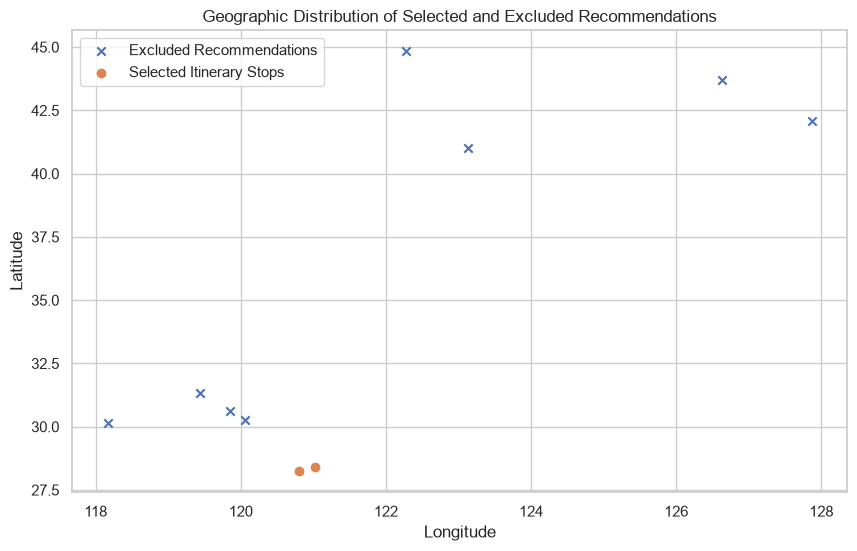

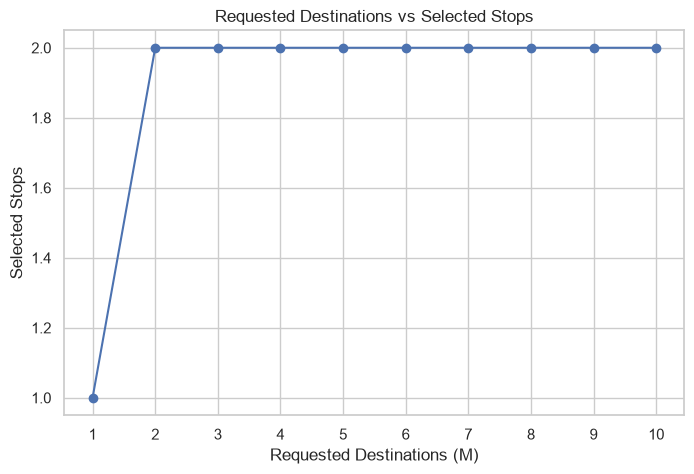

In [9]:
# Plot A: Geographic distribution of selected and excluded recommendations
plt.figure(figsize=(10, 6))

if not excluded_analysis.empty:
    plt.scatter(
        excluded_analysis["longitude"],
        excluded_analysis["latitude"],
        marker="x",
        label="Excluded Recommendations"
    )

if not itinerary.empty:
    plt.scatter(
        itinerary["longitude"],
        itinerary["latitude"],
        marker="o",
        label="Selected Itinerary Stops"
    )

plt.title("Geographic Distribution of Selected and Excluded Recommendations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


# Plot B: Requested destinations versus actual selected stops
plt.figure(figsize=(8, 5))

plt.plot(
    destination_exp_df["Requested Destinations"],
    destination_exp_df["Selected Stops"],
    marker="o"
)

plt.title("Requested Destinations vs Selected Stops")
plt.xlabel("Requested Destinations (M)")
plt.ylabel("Selected Stops")
plt.xticks(destination_exp_df["Requested Destinations"])
plt.show()

### 10. Representative Scenarios

#### Scenario A — Different Requested Destination Counts
We compare one-day itineraries generated using different requested destination counts to observe how the geographic selection constraint affects the number of attractions that can be included.

In [10]:
print("Scenario A: Requested Destination Count Comparison")

scenario_a_results = []

for requested_destinations in [1, 2, 4, 6, 8, 10]:
    itinerary = build_one_day_itinerary(
        recommendations_df=candidates_df,
        coordinates_df=coordinates_df,
        num_stops=requested_destinations
    )

    scenario_a_results.append({
        "Requested Destinations": requested_destinations,
        "Selected Stops": len(itinerary)
    })

display(pd.DataFrame(scenario_a_results))

Scenario A: Requested Destination Count Comparison


,Requested Destinations,Selected Stops
0,1,1
1,2,2
2,4,2
3,6,2
4,8,2
5,10,2


#### Scenario B — Geographically Scattered Input Recommendations
We construct a mock recommendation list containing geographically scattered attractions and apply the one-day itinerary module to examine how geographic selection handles widely separated recommendations.

In [11]:
# Create dataframe for the mock scattered recommendations
scatter_data = [
    {
        "attraction_name": "Zhu Jia Jiao Gu Zhen",
        "city": "Shanghai",
        "province": "Shanghai",
        "rating": 5.0,
        "similarity_score": 0.95
    },
    {
        "attraction_name": "Bei Jing Zhi Wu Yuan",
        "city": "Beijing",
        "province": "Beijing",
        "rating": 4.8,
        "similarity_score": 0.90
    },
    {
        "attraction_name": "San Xing Dui Yi Zhi",
        "city": "De Yang Shi",
        "province": "Sichuan",
        "rating": 4.7,
        "similarity_score": 0.88
    },
    {
        "attraction_name": "Lu Shan",
        "city": "Jiu Jiang Shi",
        "province": "Jiangxi",
        "rating": 4.6,
        "similarity_score": 0.85
    },
    {
        "attraction_name": "Zhou Zhuang Gu Zhen",
        "city": "Su Zhou Shi",
        "province": "Jiangsu",
        "rating": 4.5,
        "similarity_score": 0.82
    },
    {
        "attraction_name": "Kai Feng Fu",
        "city": "Kai Feng Shi",
        "province": "Henan",
        "rating": 4.4,
        "similarity_score": 0.80
    }
]

scatter_df = pd.DataFrame(scatter_data)

# Create attraction_uid
scatter_df["attraction_uid"] = [
    f"{row['attraction_name']} ({row['city']}, {row['province']})"
    for _, row in scatter_df.iterrows()
]

# Add recommendation rank
scatter_df["rank"] = range(1, len(scatter_df) + 1)

# Allow all mock recommendations to be considered
requested_destinations = len(scatter_df)

# Generate one-day itinerary
scenario_c_itinerary, scenario_c_excluded = build_one_day_itinerary(
    recommendations_df=scatter_df,
    coordinates_df=coordinates_df,
    num_stops=requested_destinations,
    return_excluded=True
)

print(f"Mock Recommendations: {len(scatter_df)}")
print(f"Selected for One-Day Itinerary: {len(scenario_c_itinerary)}")
print(f"Excluded: {len(scenario_c_excluded)}")


print("\n--- Selected Itinerary Stops ---")

if scenario_c_itinerary.empty:
    print("No attractions were selected.")
else:
    display(
        scenario_c_itinerary[
            [
                "stop_order",
                "attraction_name",
                "city",
                "distance_from_prev_km"
            ]
        ]
    )


print("\n--- Excluded Recommendations ---")

if scenario_c_excluded.empty:
    print("No recommendations were excluded.")
else:
    display(
        scenario_c_excluded[
            [
                "rank",
                "attraction_name",
                "city",
                "exclusion_reason"
            ]
        ].sort_values("rank")
    )

Mock Recommendations: 6
Selected for One-Day Itinerary: 2
Excluded: 4

--- Selected Itinerary Stops ---


,stop_order,attraction_name,city,distance_from_prev_km
0,1,Zhu Jia Jiao Gu Zhen,Shanghai,0.000000
1,2,Zhou Zhuang Gu Zhen,Su Zhou Shi,19.320438



--- Excluded Recommendations ---


,rank,attraction_name,city,exclusion_reason
0,2,Bei Jing Zhi Wu Yuan,Beijing,geographically_incompatible
1,3,San Xing Dui Yi Zhi,De Yang Shi,geographically_incompatible
2,4,Lu Shan,Jiu Jiang Shi,geographically_incompatible
3,6,Kai Feng Fu,Kai Feng Shi,geographically_incompatible


### 11. Implementation Observations & Interpretation
* **Geographic Coherence**: The one-day itinerary module filters geographically scattered recommendations and selects the most suitable geographic group, helping to prevent widely separated attractions from being included in the same route.
* **Requested Destination Controls**: Total stop capacities and per-day caps are strictly enforced, ensuring daily schedules match the selected travel pace (e.g. 2 stops max for Relaxed, 3 for Balanced/Packed).The requested number of destinations, M, represents the maximum number of stops the user would like to include. However, the final number of stops may be lower when insufficient recommendations satisfy the geographic selection criteria.
* **Routing Optimality**: Selected attractions are ordered using a Greedy Nearest-Neighbor heuristic based on the Haversine distance formula. The route starts from the highest-ranked selected attraction and repeatedly visits the nearest remaining attraction. This provides a practical route sequence but does not guarantee the globally shortest route.
* **Itinerary Metrics**: The metrics in src/itinerary_evaluation.py describe the geographic and structural characteristics of the generated one-day itinerary using Candidate Carryover Rate, Average Consecutive-Stop Distance, Total Travel Distance, and Geographic Compactness.